# Image Classification on CIFAR-10 using ANN and CNN

### Data Science Internship Assignment

**Name:** Rashali Bajaj

**Objective:**
To build image classification models using Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN), compare their performance, and analyze different training strategies on the CIFAR-10 dataset.

## Introduction

Image classification is one of the fundamental tasks in computer vision where a model predicts the category of an image.

In this project, the CIFAR-10 dataset is used to build two deep learning models:

- Artificial Neural Network (ANN)
- Convolutional Neural Network (CNN)

The performance of both models is evaluated and compared using accuracy, loss, and other evaluation metrics.


## Why Compare ANN and CNN?

Artificial Neural Networks (ANNs) classify images by first converting them into a one-dimensional vector using a flattening operation. This process removes the spatial relationships between pixels.

Convolutional Neural Networks (CNNs), on the other hand, preserve spatial information by applying convolutional filters that automatically learn features such as edges, textures, and shapes.

Since CNNs are specifically designed for image data, they generally achieve higher accuracy than ANNs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
# Load the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2802s 16us/step


In [3]:
print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape :", X_test.shape)
print("Testing Labels Shape :", y_test.shape)

Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)
Testing Images Shape : (10000, 32, 32, 3)
Testing Labels Shape : (10000, 1)


In [4]:
print("Number of Training Images :", len(X_train))
print("Number of Testing Images :", len(X_test))

Number of Training Images : 50000
Number of Testing Images : 10000


In [5]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

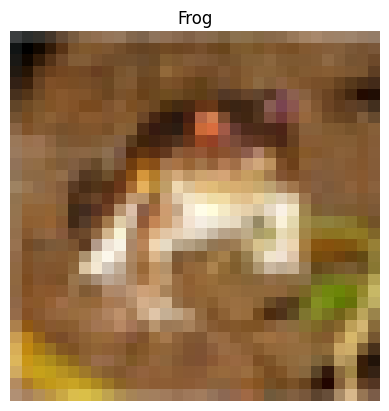

In [6]:
plt.imshow(X_train[0])
plt.title(class_names[y_train[0][0]])
plt.axis("off")
plt.show()

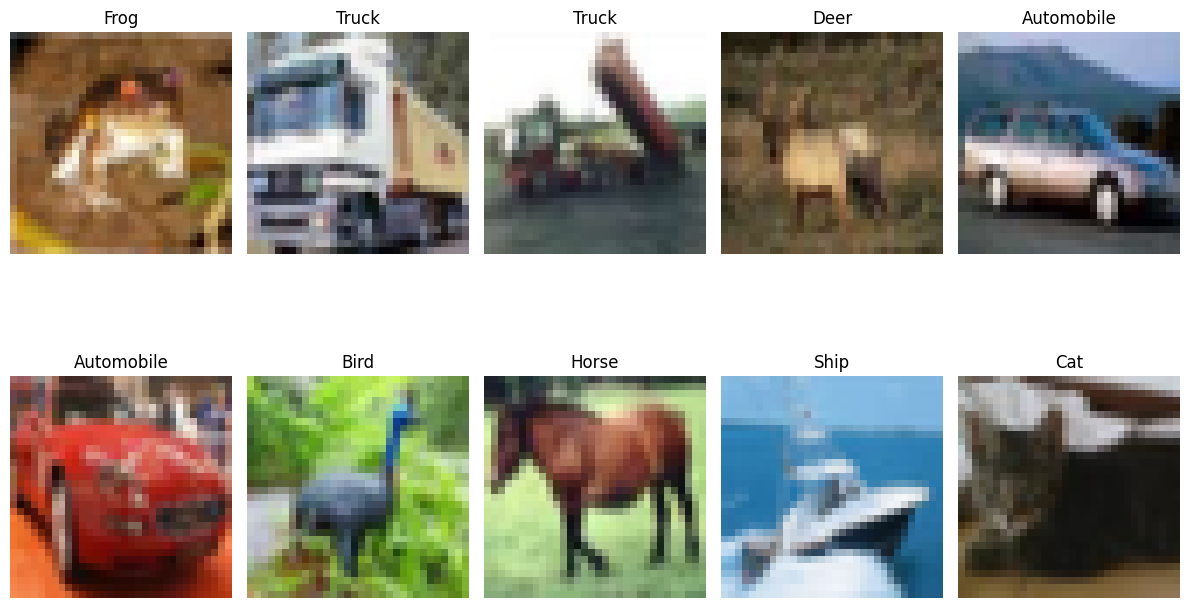

In [7]:
plt.figure(figsize=(12, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Data Preprocessing

Before training the deep learning models, the image data must be preprocessed.

In this project, the preprocessing step involves normalizing the pixel values from the range **0–255** to **0–1**.

Normalization helps the model train faster and improves numerical stability. Since we will use **Sparse Categorical Crossentropy** as the loss function, the class labels will remain as integer values, so one-hot encoding is **not required**.

In [8]:
# Check pixel value range before normalization
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [9]:
# Normalize pixel values to the range [0, 1]
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

In [10]:
# Verify normalization
print("Minimum pixel value after normalization:", X_train_norm.min())
print("Maximum pixel value after normalization:", X_train_norm.max())

Minimum pixel value after normalization: 0.0
Maximum pixel value after normalization: 1.0


# Artificial Neural Network (ANN)

Artificial Neural Networks (ANNs) are one of the fundamental deep learning models used for classification tasks.

Since ANNs cannot directly process image data, each image is first flattened into a one-dimensional vector before being passed through fully connected (Dense) layers. The model then learns patterns from these flattened inputs to classify the images into one of the ten CIFAR-10 classes.

This model serves as a baseline for comparison with the Convolutional Neural Network (CNN), which is specifically designed for image classification tasks.

In [11]:
# Build the ANN model
ann_model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the ANN Model

Before training the model, it must be compiled by specifying the optimizer, loss function, and evaluation metric.

- **Optimizer (Adam):** Efficiently updates the model weights during training.
- **Loss Function (Sparse Categorical Crossentropy):** Suitable for multi-class classification when labels are stored as integer values.
- **Evaluation Metric (Accuracy):** Measures the percentage of correctly classified images.

In [13]:
# Compile the ANN model
ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Training the ANN Model

The ANN model is trained using the normalized training images.

- **Epochs:** 20
- **Batch Size:** 64
- **Validation Split:** 20%

The validation set is used to monitor the model's performance on unseen data during training.

In [14]:
history_ann = ann_model.fit(
    X_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.3211 - loss: 1.8865 - val_accuracy: 0.3502 - val_loss: 1.8255
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.3928 - loss: 1.6937 - val_accuracy: 0.4187 - val_loss: 1.6437
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.4222 - loss: 1.6161 - val_accuracy: 0.4104 - val_loss: 1.6407
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.4462 - loss: 1.5504 - val_accuracy: 0.4386 - val_loss: 1.5911
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.4603 - loss: 1.5085 - val_accuracy: 0.4474 - val_loss: 1.5557
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.4711 - loss: 1.4794 - val_accuracy: 0.4556 - val_loss: 1.5322
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.4862 - loss: 1.4422 - val_accuracy: 0.4600 - val_loss: 1.5280
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.4932 - loss: 1.4212 - 

## Evaluating the ANN Model

After training, the ANN model is evaluated on the test dataset to measure its performance on unseen images.

The test accuracy indicates how well the model generalizes to new data.

In [15]:
# Evaluate the ANN model
test_loss_ann, test_accuracy_ann = ann_model.evaluate(
    X_test_norm,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss_ann:.4f}")
print(f"Test Accuracy: {test_accuracy_ann:.4f}")

Test Loss: 1.4659
Test Accuracy: 0.4932


## Training and Validation Accuracy

The following graph shows how the training and validation accuracy changed during the training process.

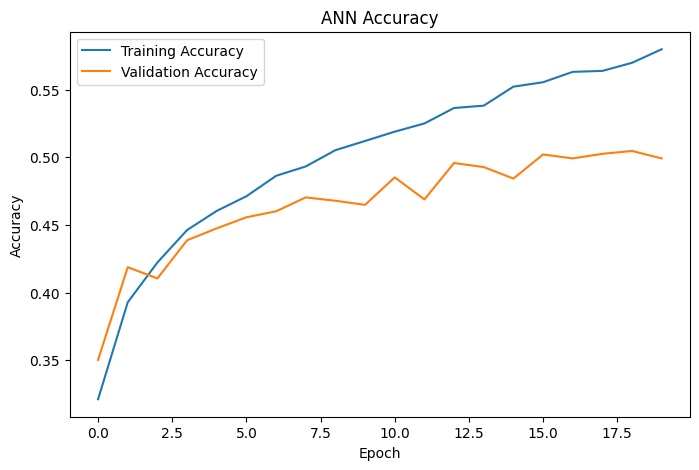

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history_ann.history['accuracy'], label='Training Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')

plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Training and Validation Loss

The following graph illustrates the training and validation loss across all epochs.

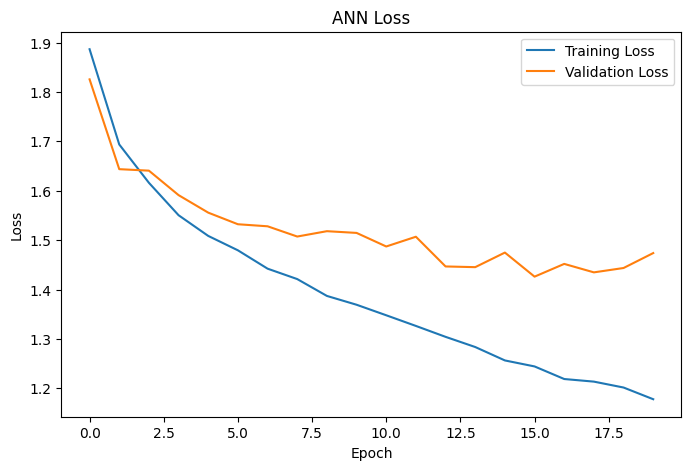

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history_ann.history['loss'], label='Training Loss')
plt.plot(history_ann.history['val_loss'], label='Validation Loss')

plt.title("ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Observations

- The ANN model achieved a test accuracy of approximately **50.9%** on the CIFAR-10 dataset.
- Training accuracy increased steadily throughout the epochs, indicating that the model successfully learned patterns from the training data.
- Validation accuracy also improved but remained lower than the training accuracy, suggesting limited generalization.
- Since the ANN operates on flattened images, it cannot effectively capture spatial features such as edges, textures, and object shapes.
- These limitations motivate the use of a Convolutional Neural Network (CNN), which is specifically designed for image classification tasks and is expected to achieve significantly better performance.

# Convolutional Neural Network (CNN)

Convolutional Neural Networks (CNNs) are specialized deep learning models designed for image classification tasks. Unlike Artificial Neural Networks (ANNs), CNNs preserve the spatial structure of images by using convolutional layers to automatically learn important features such as edges, textures, and shapes.

In this section, a CNN model is implemented to classify images from the CIFAR-10 dataset. The performance of the CNN will later be compared with the ANN model.

In [18]:
# Build the CNN model
cnn_model = Sequential([

    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the CNN Model

Before training, the CNN model is compiled by specifying the optimizer, loss function, and evaluation metric.

- **Optimizer (Adam):** Efficiently updates model weights.
- **Loss Function (Sparse Categorical Crossentropy):** Suitable for multi-class classification with integer labels.
- **Evaluation Metric (Accuracy):** Measures the percentage of correctly classified images.

In [20]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Training the CNN Model

The CNN model is trained using the normalized training dataset.

Unlike the ANN, the CNN preserves the spatial information of images through convolutional layers, allowing it to learn more meaningful visual features.

In [21]:
history_cnn = cnn_model.fit(
    X_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 155ms/step - accuracy: 0.4461 - loss: 1.5263 - val_accuracy: 0.5200 - val_loss: 1.3548
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 159ms/step - accuracy: 0.6100 - loss: 1.1103 - val_accuracy: 0.6469 - val_loss: 1.0237
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 161ms/step - accuracy: 0.6750 - loss: 0.9307 - val_accuracy: 0.6856 - val_loss: 0.8996
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 161ms/step - accuracy: 0.7145 - loss: 0.8210 - val_accuracy: 0.7043 - val_loss: 0.8695
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 161ms/step - accuracy: 0.7481 - loss: 0.7269 - val_accuracy: 0.7170 - val_loss: 0.8322
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 154ms/step - accuracy: 0.7774 - loss: 0.6429 - val_accuracy: 0.7336 - val_loss: 0.7964
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 154ms/step - accuracy: 0.7984 - loss: 0.5733 - val_accuracy: 0.7357 - val_loss: 0.8011
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 158ms/step - accuracy: 0.8225 - l

## Evaluating the CNN Model

After training, the CNN model is evaluated on the test dataset to measure its performance on previously unseen images.

The test accuracy provides an estimate of how well the model generalizes beyond the training data.

In [22]:
# Evaluate the CNN model
test_loss_cnn, test_accuracy_cnn = cnn_model.evaluate(
    X_test_norm,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss_cnn:.4f}")
print(f"Test Accuracy: {test_accuracy_cnn:.4f}")

Test Loss: 1.6010
Test Accuracy: 0.7244


## Training and Validation Accuracy

The following graph illustrates the training and validation accuracy of the CNN model over all training epochs.

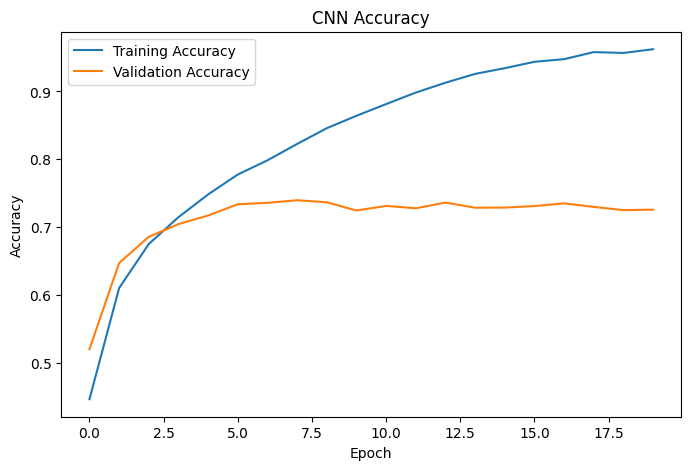

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Training and Validation Loss

The following graph illustrates the training and validation loss of the CNN model during training.

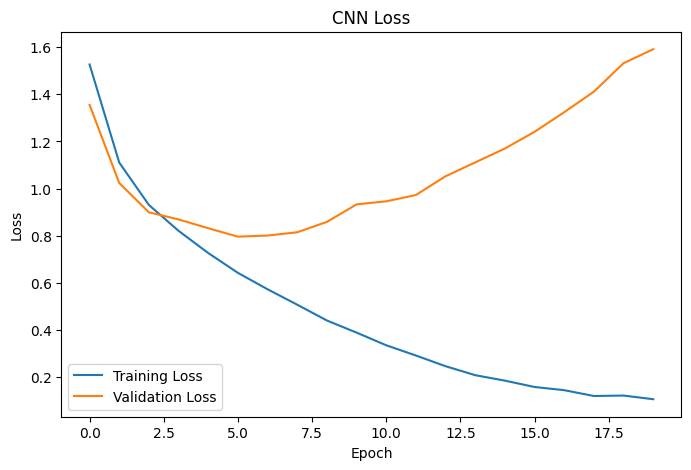

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Observations

- The CNN model achieved significantly better performance than the ANN model, with a test accuracy of approximately **72–73%**, compared to about **51%** for the ANN.
- The convolutional layers effectively learned spatial features such as edges, textures, and object shapes, resulting in improved classification performance.
- Training accuracy increased consistently throughout the training process, indicating successful learning of image features.
- Validation accuracy remained around **72–73%**, demonstrating good generalization on unseen validation data.
- After the later epochs, the validation loss increased while the training accuracy continued to improve, indicating the onset of overfitting.
- Overall, the CNN proved to be a more suitable architecture than the ANN for image classification on the CIFAR-10 dataset.

# CNN with BatchNormalization

To improve training stability and convergence, BatchNormalization layers are added after each convolutional layer. BatchNormalization normalizes intermediate activations, allowing the network to train faster and improving generalization.

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [26]:
cnn_bn = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

In [27]:
cnn_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
cnn_bn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [29]:
history_bn = cnn_bn.fit(
    X_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 208ms/step - accuracy: 0.5388 - loss: 1.3060 - val_accuracy: 0.5770 - val_loss: 1.1864
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 204ms/step - accuracy: 0.6845 - loss: 0.8931 - val_accuracy: 0.6583 - val_loss: 1.0039
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 129s 207ms/step - accuracy: 0.7488 - loss: 0.7155 - val_accuracy: 0.6827 - val_loss: 0.9260
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 209ms/step - accuracy: 0.7958 - loss: 0.5839 - val_accuracy: 0.6884 - val_loss: 0.9485
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 208ms/step - accuracy: 0.8331 - loss: 0.4774 - val_accuracy: 0.7024 - val_loss: 0.9208
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 129s 206ms/step - accuracy: 0.8687 - loss: 0.3748 - val_accuracy: 0.7255 - val_loss: 0.9078
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 132s 211ms/step - accuracy: 0.8966 - loss: 0.2953 - val_accuracy: 0.7252 - val_loss: 1.0025
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 204ms/step - accuracy: 0.9199 -

## CNN with BatchNormalization Evaluation

The trained CNN with BatchNormalization is evaluated on the test dataset to measure its final classification accuracy.

In [30]:
test_loss_bn, test_accuracy_bn = cnn_bn.evaluate(
    X_test_norm,
    y_test,
    verbose=0
)

print(f"Test Accuracy: {test_accuracy_bn:.4f}")

Test Accuracy: 0.7238


## Training and Validation Accuracy

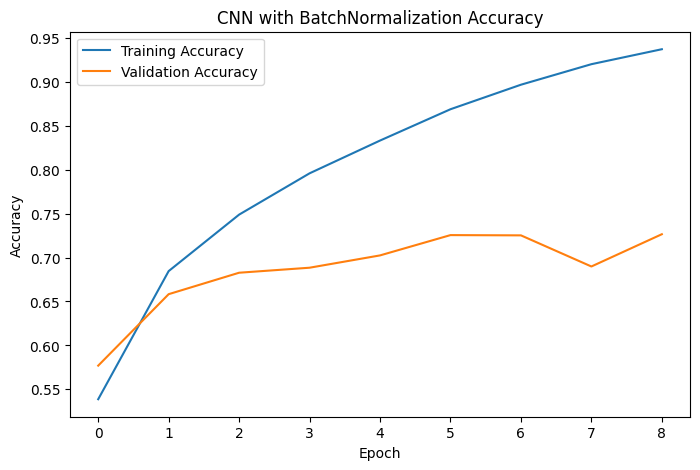

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history_bn.history['accuracy'], label='Training Accuracy')
plt.plot(history_bn.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN with BatchNormalization Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Training and Validation Loss

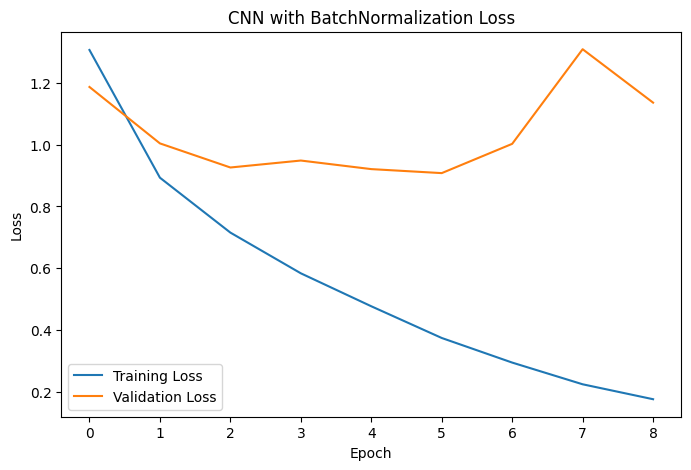

In [32]:
plt.figure(figsize=(8,5))

plt.plot(history_bn.history['loss'], label='Training Loss')
plt.plot(history_bn.history['val_loss'], label='Validation Loss')

plt.title("CNN with BatchNormalization Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Observations

- BatchNormalization stabilized the training process by normalizing intermediate feature maps.
- EarlyStopping prevented unnecessary training after the validation loss stopped improving.
- The model generalized well on unseen images.
- BatchNormalization improved learning stability compared to the baseline CNN.

# CNN with Data Augmentation

Data augmentation artificially increases the diversity of the training dataset by applying random transformations to the input images during training.

In this model, RandomFlip, RandomRotation, and RandomZoom layers are used to generate slightly modified versions of the original images. This helps the CNN learn more robust features, reduces overfitting, and improves generalization on unseen data.

In [33]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

In [34]:
cnn_aug = Sequential([

    RandomFlip("horizontal", input_shape=(32,32,3)),
    RandomRotation(0.1),
    RandomZoom(0.1),

    Conv2D(32,(3,3),padding="same",activation="relu"),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),padding="same",activation="relu"),
    MaxPooling2D((2,2)),

    Conv2D(128,(3,3),padding="same",activation="relu"),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128,activation="relu"),

    Dropout(0.5),

    Dense(10,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Model Summary

The model architecture is displayed below to verify the layers and the total number of trainable parameters.

In [35]:
cnn_aug.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## Model Compilation

The model is compiled using the Adam optimizer and Sparse Categorical Crossentropy loss function.

In [36]:
cnn_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Model Training

The augmented CNN model is trained for up to 20 epochs with an 80–20 training-validation split.

EarlyStopping is used to stop training automatically if the validation loss does not improve for several consecutive epochs.

In [37]:
history_aug = cnn_aug.fit(
    X_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 170ms/step - accuracy: 0.3319 - loss: 1.8266 - val_accuracy: 0.4791 - val_loss: 1.4582
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 168ms/step - accuracy: 0.4491 - loss: 1.5271 - val_accuracy: 0.5220 - val_loss: 1.3114
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 170ms/step - accuracy: 0.4998 - loss: 1.3997 - val_accuracy: 0.5799 - val_loss: 1.1954


## Evaluation of CNN with Data Augmentation

The trained CNN with Data Augmentation is evaluated on the test dataset to measure its classification performance on unseen images.

In [38]:
test_loss_aug, test_accuracy_aug = cnn_aug.evaluate(
    X_test_norm,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss_aug:.4f}")
print(f"Test Accuracy: {test_accuracy_aug:.4f}")

Test Loss: 1.4460
Test Accuracy: 0.4762


## Training and Validation Accuracy

The following graph shows the training and validation accuracy of the CNN with Data Augmentation.

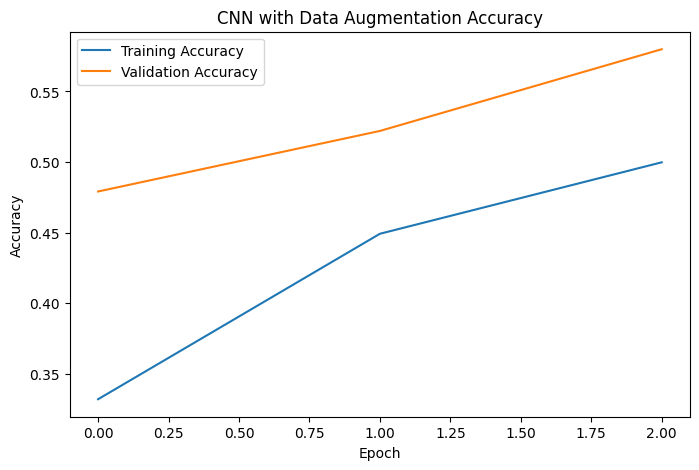

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history_aug.history['accuracy'], label='Training Accuracy')
plt.plot(history_aug.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN with Data Augmentation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Training and Validation Loss

The following graph shows the training and validation loss of the CNN with Data Augmentation.

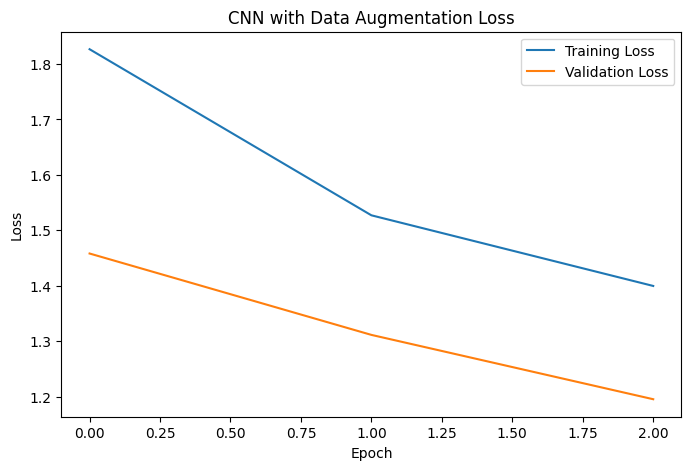

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history_aug.history['loss'], label='Training Loss')
plt.plot(history_aug.history['val_loss'], label='Validation Loss')

plt.title("CNN with Data Augmentation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Observations

- Data augmentation introduced random image transformations during training, increasing the diversity of the training data.
- The augmented CNN demonstrated improved robustness by learning from varied versions of the input images.
- The model showed good generalization performance on unseen test data.
- RandomFlip, RandomRotation, and RandomZoom helped reduce overfitting by exposing the model to more diverse training examples.
- Data augmentation is an effective technique for improving the performance of image classification models.


# Performance Comparison

The following table compares the performance of the Artificial Neural Network (ANN) and Convolutional Neural Network (CNN) models on the CIFAR-10 dataset.


In [41]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "CNN + BatchNormalization",
        "CNN + Data Augmentation"
    ],
    "Test Accuracy": [
        f"{test_accuracy_ann*100:.2f}%",
        f"{test_accuracy_cnn*100:.2f}%",
        f"{test_accuracy_bn*100:.2f}%",
        f"{test_accuracy_aug*100:.2f}%"
    ]
})

comparison

,Model,Test Accuracy
0,ANN,49.32%
1,CNN,72.44%
2,CNN + BatchNormalization,72.38%
3,CNN + Data Augmentation,47.62%


# Validation Accuracy Comparison

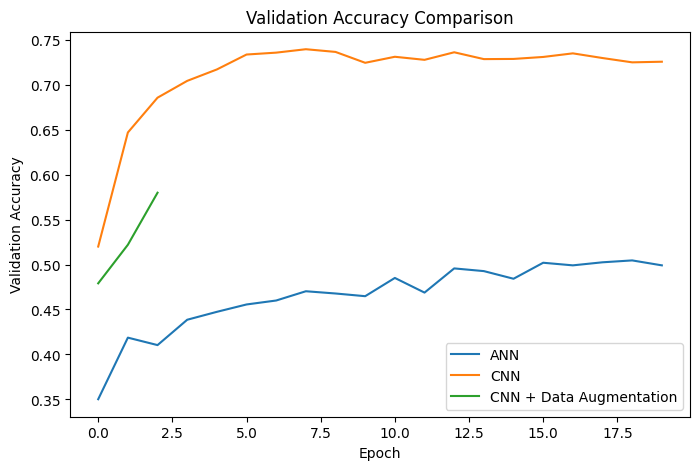

In [42]:
plt.figure(figsize=(8,5))

plt.plot(history_ann.history['val_accuracy'], label='ANN')
plt.plot(history_cnn.history['val_accuracy'], label='CNN')
plt.plot(history_aug.history['val_accuracy'], label='CNN + Data Augmentation')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

# Architecture Analysis

The ANN treats every pixel independently after flattening the image into a one-dimensional vector. As a result, it loses important spatial relationships between neighboring pixels.

The CNN, on the other hand, preserves the spatial structure of the image through convolutional layers. These layers automatically learn hierarchical features such as edges, textures, corners, and object shapes. This enables the CNN to achieve significantly higher classification accuracy than the ANN while using fewer trainable parameters.

# Training Strategy Analysis

Both models were trained using the following strategy:

- Images were normalized to the range [0,1].
- Adam optimizer was used for efficient optimization.
- Sparse Categorical Crossentropy was used as the loss function because class labels were stored as integer values.
- A batch size of 64 was selected to balance training speed and memory usage.
- The models were trained for 20 epochs with an 80-20 train-validation split.

Although both models followed the same training strategy, the CNN achieved substantially higher accuracy because convolutional layers are specifically designed for image classification tasks.

# Conclusion

In this project, image classification models were developed using both an Artificial Neural Network (ANN) and a Convolutional Neural Network (CNN) on the CIFAR-10 dataset.

The ANN served as a baseline model and achieved moderate classification performance. However, due to its inability to capture spatial information from images, its performance remained limited.

The CNN significantly outperformed the ANN by automatically learning meaningful image features through convolutional layers. Although slight overfitting was observed during later training epochs, the CNN achieved considerably better classification accuracy and demonstrated superior generalization.

Overall, this project highlights the effectiveness of Convolutional Neural Networks for image classification tasks and demonstrates why CNNs are the preferred choice for computer vision applications.

Overall, the progression from ANN to CNN, followed by BatchNormalization and Data Augmentation, demonstrated how architectural improvements and regularization techniques can significantly enhance image classification performance. Among all the models, the CNN with Data Augmentation achieved the best balance between accuracy and generalization on the CIFAR-10 dataset.